`DeepField` framework can be used for advanced data manipulation obtained as the results of `JutulDarcy.jl`, a fully differentiable reservoir simulator written in `Julia`. Interconnection between `Field` object and `JutulDarcy` can be established by python wrapper `PyJutulDarcy` (https://github.com/sintefmath/PyJutulDarcy).

The package can be installed with pip: `pip install jutuldarcy`

The package also provides access to all the functions of the Julia version under `jutuldarcy.jl.JutulDarcy`, `jutuldarcy.jl.GeoEnergyIO` and `jutuldarcy.jl.Jutul`. These functions are directly wrapped using `JuliaCall`. For more details, see the JuliaCall Documentation (https://juliapy.github.io/PythonCall.jl/stable/juliacall/). On first time usage of the package `JuliaCall` will automatically install `Julia` and manage all dependency packages.

Workflow consists of the following steps
- loading "empty" model that doesn't contain dynamical data (pressure, saturations and well-rates) as `Field` object
- loading the same model but using `PyJutulDarcy` methods for reading `.DATA` files
- running simulation in `PyJutulDarcy`. Results are python dicts and numpy arrays
- assign arrays to `Field` model as attributes

Required imports:

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import timedelta
import matplotlib.pyplot as plt

import jutuldarcy as jd
from juliacall import Main as jl

import sys
sys.path.append("..")

from deepfield import Field

C:\Users\mushe\anaconda3\envs\deepfield\Lib\site-packages\jutuldarcy\julia_import.py:9: UserWarning: juliacall module already imported. Make sure that you have set the environment variable `PYTHON_JULIACALL_HANDLE_SIGNALS=yes` to avoid segfaults. Also note that jutuldarcy will not be able to configure `PYTHON_JULIACALL_THREADS` or `PYTHON_JULIACALL_OPTLEVEL` for you.
  warnings.warn(


Setting up `.DATA`-file path and loading static reservoir model as `Field` object

In [3]:
path = '../open_data/egg/Egg_Model_ECL.DATA'
model = Field(path).load()

INFO:Field:Using default config.
INFO:Field:Start reading Egg_Model_ECL.DATA
INFO:Field:Reading section RUNSPEC
INFO:Field:[Egg_Model_ECL.DATA:9] Loading TITLE
INFO:Field:[Egg_Model_ECL.DATA:16] Loading DIMENS
INFO:Field:[Egg_Model_ECL.DATA:19] Loading METRIC
INFO:Field:[Egg_Model_ECL.DATA:20] Loading OIL
INFO:Field:[Egg_Model_ECL.DATA:21] Loading WATER
INFO:Field:[Egg_Model_ECL.DATA:41] Loading START
INFO:Field:Reading section GRID
INFO:Field:[Egg_Model_ECL.DATA:55] Include D:\RnD\StudyProjects\deepfield-team\DeepField\open_data\egg\ACTIVE.INC
INFO:Field:Start reading ACTIVE.INC
INFO:Field:[ACTIVE.INC:1] Loading ACTNUM
INFO:Field:Finish reading ACTIVE.INC
INFO:Field:[Egg_Model_ECL.DATA:58] Loading DX
INFO:Field:[Egg_Model_ECL.DATA:62] Loading DY
INFO:Field:[Egg_Model_ECL.DATA:66] Loading DZ
INFO:Field:[Egg_Model_ECL.DATA:69] Loading TOPS
INFO:Field:[Egg_Model_ECL.DATA:73] Include D:\RnD\StudyProjects\deepfield-team\DeepField\open_data\egg\mDARCY.INC
INFO:Field:Start reading mDARCY.INC

`PyJutulDarcy` allows reading `.DATA` files, which are converted into a `Jutul` data structure containing following field: 

- `dt` - report steps
- `forces` - control and boundary values
- `input_data` - dict-like data structure containing sections of the `.DATA` file (see below)
- `model` - variables and equations used in simulation
- `parameters` - parameters of the model to which can be computed sensitivities
- `state0` - initial state

In [4]:
case = jd.setup_case_from_data_file(path)

In [5]:
case.input_data

Dict{String, Any} with 7 entries:
  "RUNSPEC"  => OrderedDict{String, Any}("TITLE"=>"Egg_Model", "UNIFOUT"=>true,…
  "GRID"     => OrderedDict{String, Any}("cartDims"=>(60, 60, 7), "CURRENT_BOX"…
  "REGIONS"  => OrderedDict{String, Any}()
  "PROPS"    => OrderedDict{String, Any}("DENSITY"=>Any[[900.0, 1000.0, 1.0]], …
  "SUMMARY"  => OrderedDict{String, Any}()
  "SCHEDULE" => Dict{String, Any}("STEPS"=>OrderedDict{String, Any}[OrderedDict…
  "SOLUTION" => OrderedDict{String, Any}("EQUIL"=>Any[[4000.0, 4.0e7, 5000.0, 0…

At the same time, `.DATA` files can be loaded directly from disk and simulated in `PyJutulDarcy`

In [6]:
res = jd.simulate_data_file(path, convert = True, info_level = -1)

Result is again a python nested dictionary (`json`-like) structure that stores information about control and states per report timestep as regular `ndarray`

In [7]:
res.keys()

dict_keys(['WELLS', 'FIELD', 'DAYS', 'STATES'])

For example, the `STATES` key is a list of length the number of report steps, with a dictionary for each time step.

In [8]:
len(res['STATES'])

120

In [9]:
res['STATES'][0].keys()

dict_keys(['Saturations', 'Pressure', 'TotalMasses'])

Below is an example of `ndarray` with values of saturations at the first timestep (remember initial state is not returned by `jd.simulate_data_file` for state and wells)

In [10]:
res['STATES'][0]['Saturations'].shape

(2, 18553)

`WELLS` key is slightly different. Its keys are well names:

In [11]:
res['WELLS'].keys()

dict_keys(['PROD2', 'INJECT5', 'INJECT4', 'INJECT2', 'INJECT1', 'PROD1', 'PROD4', 'INJECT6', 'INJECT7', 'INJECT3', 'PROD3', 'INJECT8'])

and keys for concrete well

In [12]:
res['WELLS']['PROD1'].keys()

dict_keys(['WWPT', 'WWIR', 'WGPR', 'WOIT', 'WOPT', 'WBHP', 'WWCT', 'WOIR', 'WGPT', 'WLPR', 'WWPR', 'WGIR', 'WGIT', 'WWIT', 'WGOR', 'WOPR'])

well rate is `ndarray` of length the number of report steps

In [13]:
res['WELLS']['PROD1']['WOPR']

array([132.22768033, 132.96844124, 133.4234874 , 133.96875998,
       137.7073083 , 145.57428096, 149.63446932, 153.75186771,
       156.22647403, 157.27856926, 156.71908812, 148.88904438,
       125.2202232 , 100.95410883,  79.67969295,  68.55132183,
        62.37586242,  56.77451501,  51.35678004,  45.6539295 ,
        38.9322978 ,  33.98656882,  30.5287553 ,  27.67712068,
        25.1888681 ,  23.09237971,  21.27481546,  19.72459412,
        18.47989145,  17.37096689,  16.32958976,  15.35644307,
        14.47105944,  13.64856658,  12.87957472,  12.1647638 ,
        11.50856959,  10.92155854,  10.39460647,   9.92714944,
         9.5170406 ,   9.14526399,   8.79563213,   8.46070113,
         8.13441587,   7.82366821,   7.5308083 ,   7.25800874,
         7.00492199,   6.77695001,   6.57261115,   6.38457509,
         6.21118448,   6.05077975,   5.90262436,   5.76460841,
         5.63530217,   5.51368895,   5.3982515 ,   5.28923737,
         5.18484475,   5.08495024,   4.98853503,   4.89

As mentioned earlier, the simulation output will not contain any initial state data. Therefore, to obtain the final results, we will need access to the assembled `case` data structure. It uses `JuliaCall` functions to run commands from `Julia`.

In [14]:
state0_pressure = np.array(
    jl.seval("state0 -> state0[:Reservoir][:Pressure]")(case.state0)
).reshape(1, -1)

state0_sats = np.array(
    jl.seval("state0 -> state0[:Reservoir][:Saturations]")(case.state0)
).reshape(1, 2, -1)

As the results returned by `jd.simulate_data_file` contain python dictionary with ndarrays, they can be manipulated inside python scientific workflow. First they are reshaped to  `n_timesteps x n_active_cells`

In [15]:
n_steps = len(res['STATES'])
jd_pressure = np.array([res['STATES'][i]['Pressure'] for i in range(n_steps)])
jd_sats = np.array([res['STATES'][i]['Saturations'] for i in range(n_steps)])

Initial states must be added to `jd_pressure` and `jd_sats`

In [16]:
jd_pressure = np.vstack([state0_pressure, jd_pressure])
jd_sats = np.vstack([state0_sats, jd_sats])

Than mean pressure and saturations can be plotted

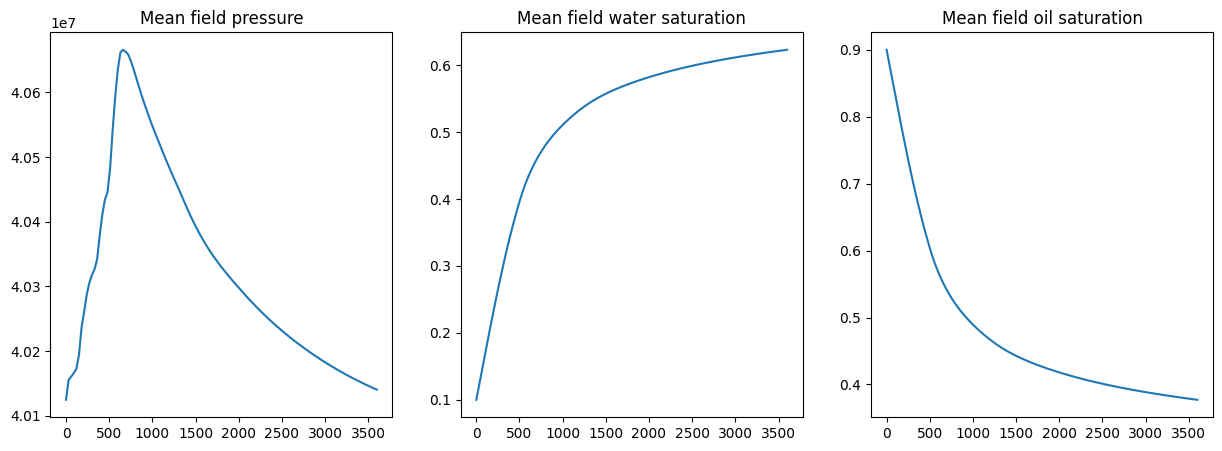

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

days = np.hstack([0., res["DAYS"]])
pressure = jd_pressure.mean(axis=1)
swat = jd_sats[:, 0, :].mean(axis=1)
soil = jd_sats[:, 1, :].mean(axis=1)

ax[0].set_title("Mean field pressure")
ax[0].plot(days, pressure)
ax[1].set_title("Mean field water saturation")
ax[1].plot(days, swat)
ax[2].set_title("Mean field oil saturation")
ax[2].plot(days, soil)

The model previously loaded as a `Field` object does not contain any states:

In [18]:
model.states.attributes

()

But now, thanks to the calculated saturation and pressure dynamics, states can be assigned to the Deepfield model:

In [19]:
model.states.pressure = jd_pressure
model.states.soil = jd_sats[:, 1, :]
model.states.swat = jd_sats[:, 0, :]

Next step is to transform 1D-arrays assigned to the model's states as 3D ones

In [20]:
model.states.to_spatial()

Then such spatially-distributed properties as pressure and saturations at chosen timestep can be visualizaed immediately

C:\Users\mushe\anaconda3\envs\deepfield\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


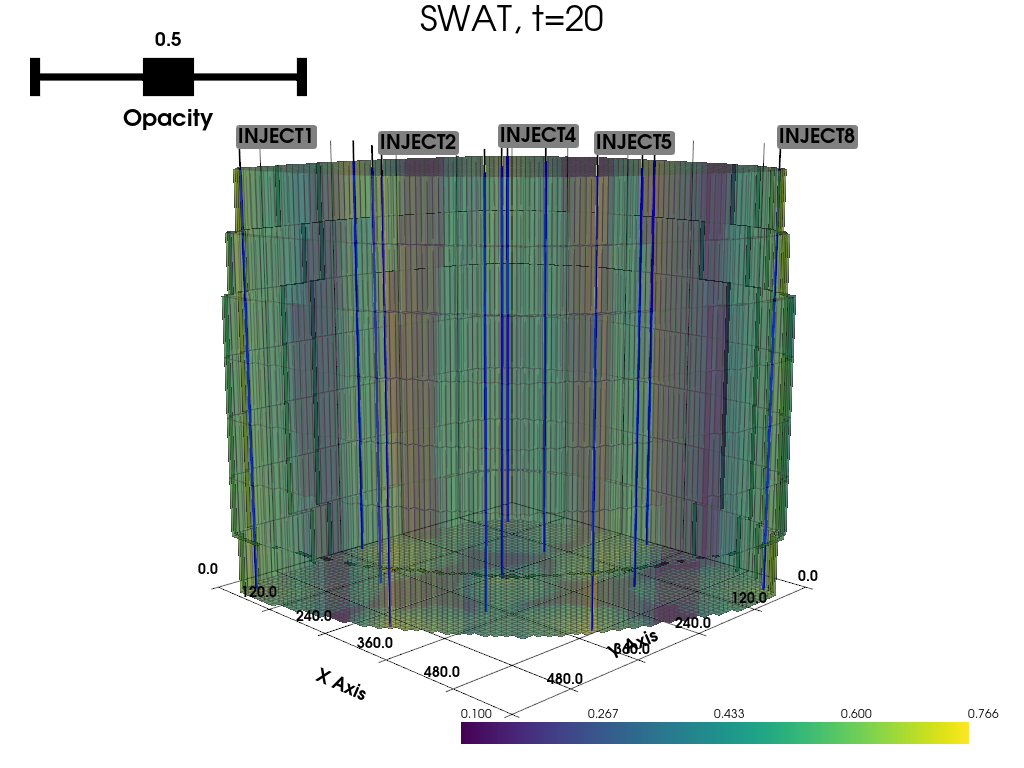

In [21]:
model.show(attr="SWAT", timestamp=20, notebook=True)

For assignment of the well rate, frist extract report dates:

In [22]:
n_timestamps = len(res["DAYS"])
start_date = case.input_data["RUNSPEC"]["START"]
timestamps = [start_date + timedelta(days=res["DAYS"][i]) for i in range(n_timestamps)]
dates = pd.DataFrame({"DATE": timestamps})

Well states can be updated from dictionary `welldata` with keys - well names, and values - dataframes with the well states. Create an empty `welldata`:

In [23]:
welldata = {}

Auxiliary function for collecting computed well rates into dataframe

In [24]:
def well_states(well):
    states_df = pd.concat([dates, pd.DataFrame(well)], axis=1)
    record0 = pd.DataFrame([[start_date] + [0.0]*(len(well.columns))], columns = states_df.columns)
    states_df = pd.concat([record0, states_df])
    return states_df

Forming `welldata` dictionary

In [25]:
wellnames = res["WELLS"].keys()
welldata = {w: {"RESULTS": well_states(pd.DataFrame(res["WELLS"][w]))} for w in wellnames}

Assigning `welldata` structure to wells by `wells.update` method

In [26]:
model.wells.update(welldata)

Now it is possible to run
```python
model_with_rates.wells.show_rates()
``` 
and show well rates from `JutulDarcy`

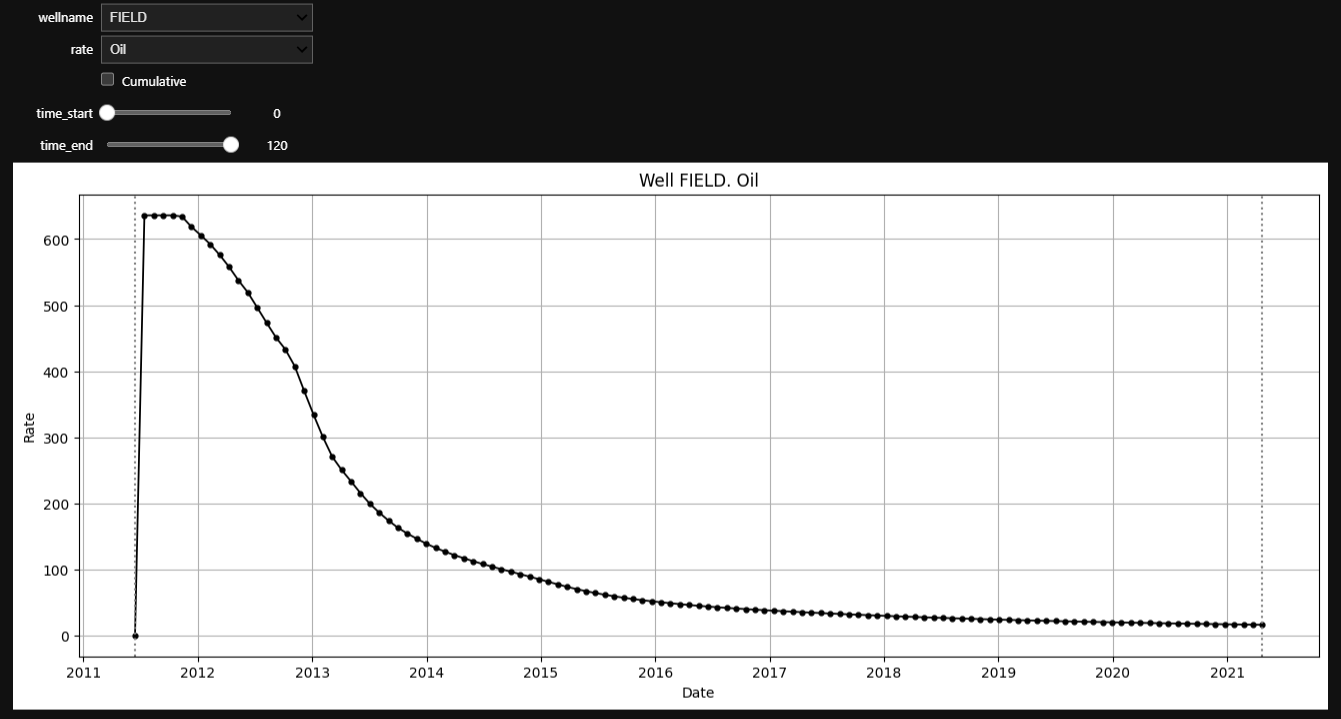